[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jinming99/learn-ml-by-building/blob/main/Lecture%204%20Optimization/04-Optimization-GD.ipynb)

# Gradient Descent and Optimization: From Theory to Practice

## Today's Mission

Understand how a model moves from a poor set of parameters to a useful one—and how learning rate, feature scale, and batch size shape that journey.

By the end of this lecture, you will be able to formulate an optimization problem, derive and implement gradient descent, reason about learning rate and feature scaling, and compare batch, stochastic, and mini-batch gradient estimates.


## Part 1: The Optimization View of Machine Learning

Training means choosing parameters $\theta$ that minimize an objective:

$$\theta^* = \arg\min_\theta L(\theta).$$

For linear regression, the parameters are a weight and bias, predictions are $\hat y=wx+b$, and the objective is mean squared error. The optimizer changes $w$ and $b$; the loss tells it whether those changes helped.


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
import ipywidgets as widgets

np.random.seed(42)
plot_style = next(
    (name for name in ('seaborn-v0_8-darkgrid', 'seaborn-darkgrid')
     if name in plt.style.available),
    'default',
)
plt.style.use(plot_style)
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

COLORS = {
    'data': '#9aa0a6',
    'current': '#e74c3c',
    'gradient': '#f39c12',
    'step': '#2ecc71',
    'optimum': '#3498db',
    'stochastic': '#e67e22',
}

def style_plot(ax, title, xlabel, ylabel):
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.25)
    ax.spines[['top', 'right']].set_visible(False)



### A Concrete Objective: California Housing

We will fit one interpretable relationship—median income to median house value—so that both the model and its complete loss landscape remain visible. Before fitting anything, inspect the scatter: what structure in the data might a simple regression model struggle to represent?


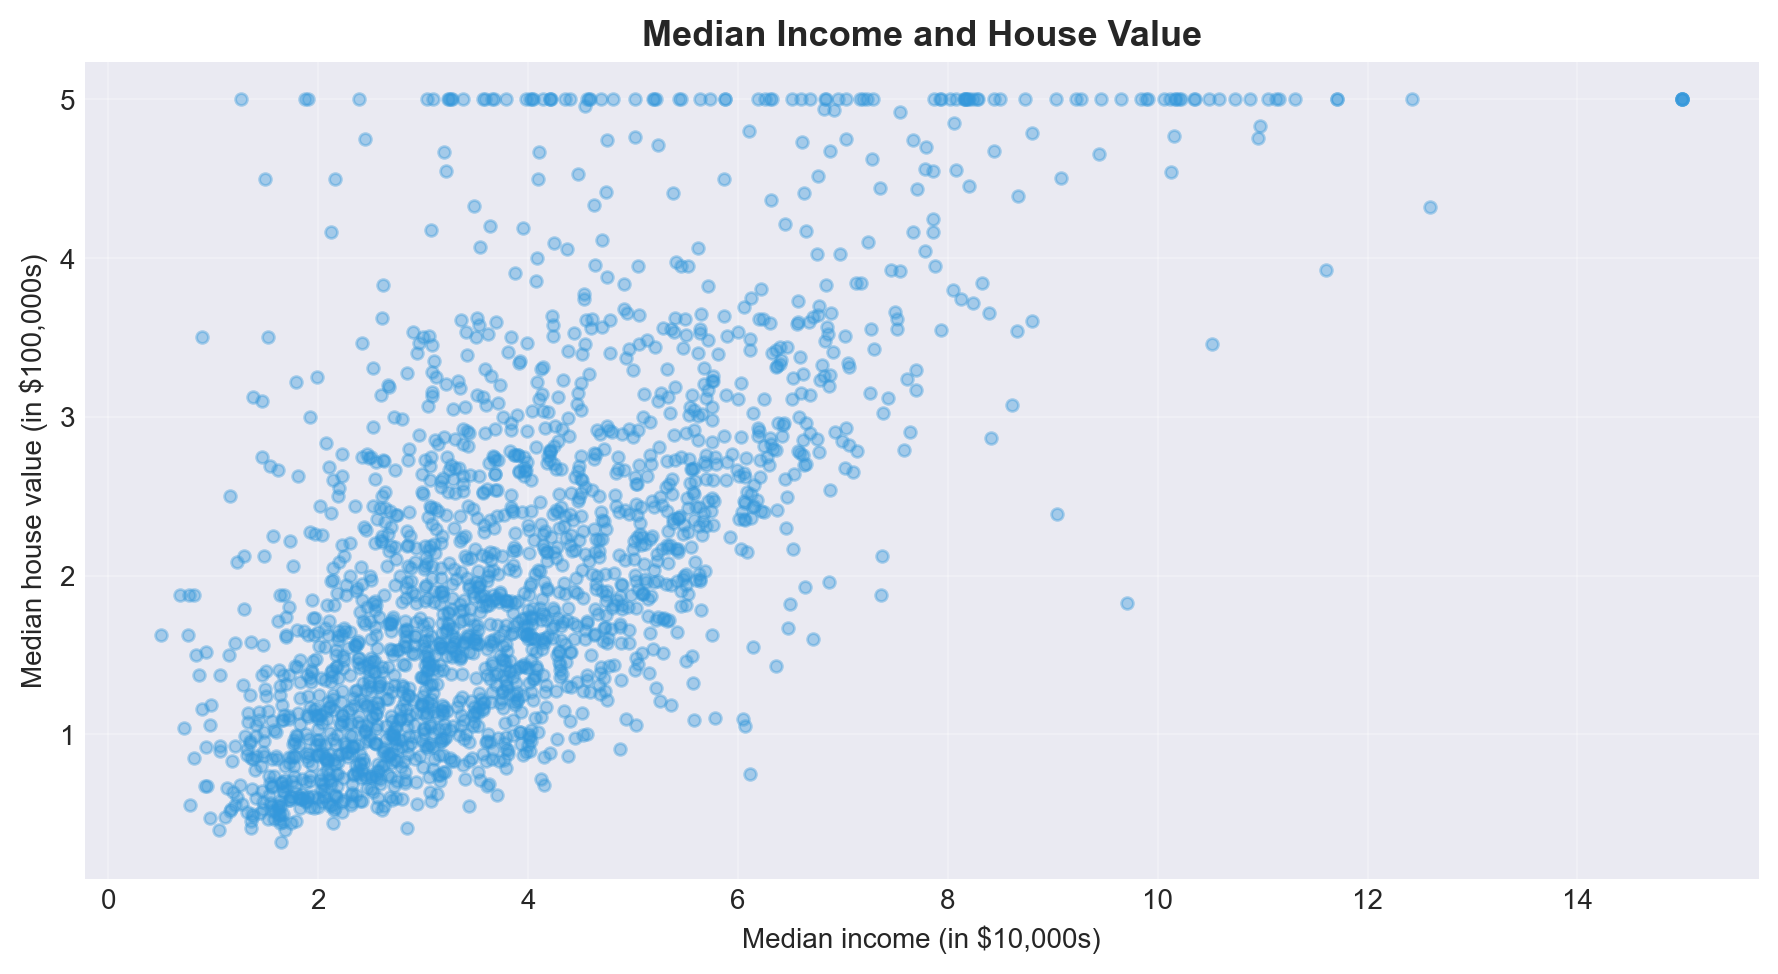

In [32]:
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['target'] = housing.target

rng = np.random.default_rng(42)
sample_indices = rng.choice(len(df), 2_000, replace=False)
X_raw = df.loc[sample_indices, 'MedInc'].to_numpy()
y_raw = df.loc[sample_indices, 'target'].to_numpy()

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(X_raw, y_raw, s=18, alpha=0.38, color=COLORS['optimum'])
style_plot(ax, 'Median Income and House Value',
           'Median income (in $10,000s)', 'Median house value (in $100,000s)')
plt.tight_layout()
plt.show()

### When Flexibility Becomes Fragility

Imagine a small appraisal office with only 100 recent sales. It expands eight measurements into 44 main effects and pairwise interactions—almost one coefficient for every two observations. Unconstrained least squares is free to use large, offsetting coefficients to chase accidental patterns.

We compare that fit with an $L_2$ constraint,

$$\min_w \operatorname{MSE}(w)\quad\text{subject to}\quad \lVert w\rVert_2\le R.$$

The code uses ridge regression to select the constraint strength from the training sample; for a corresponding $R$ and $\lambda$, the constrained and penalized formulations have the same solution. Values outside $[0,5]$ are outside this dataset's **recorded** target range—the upper endpoint is a data-collection ceiling, not a claim that real homes cannot be worth more.


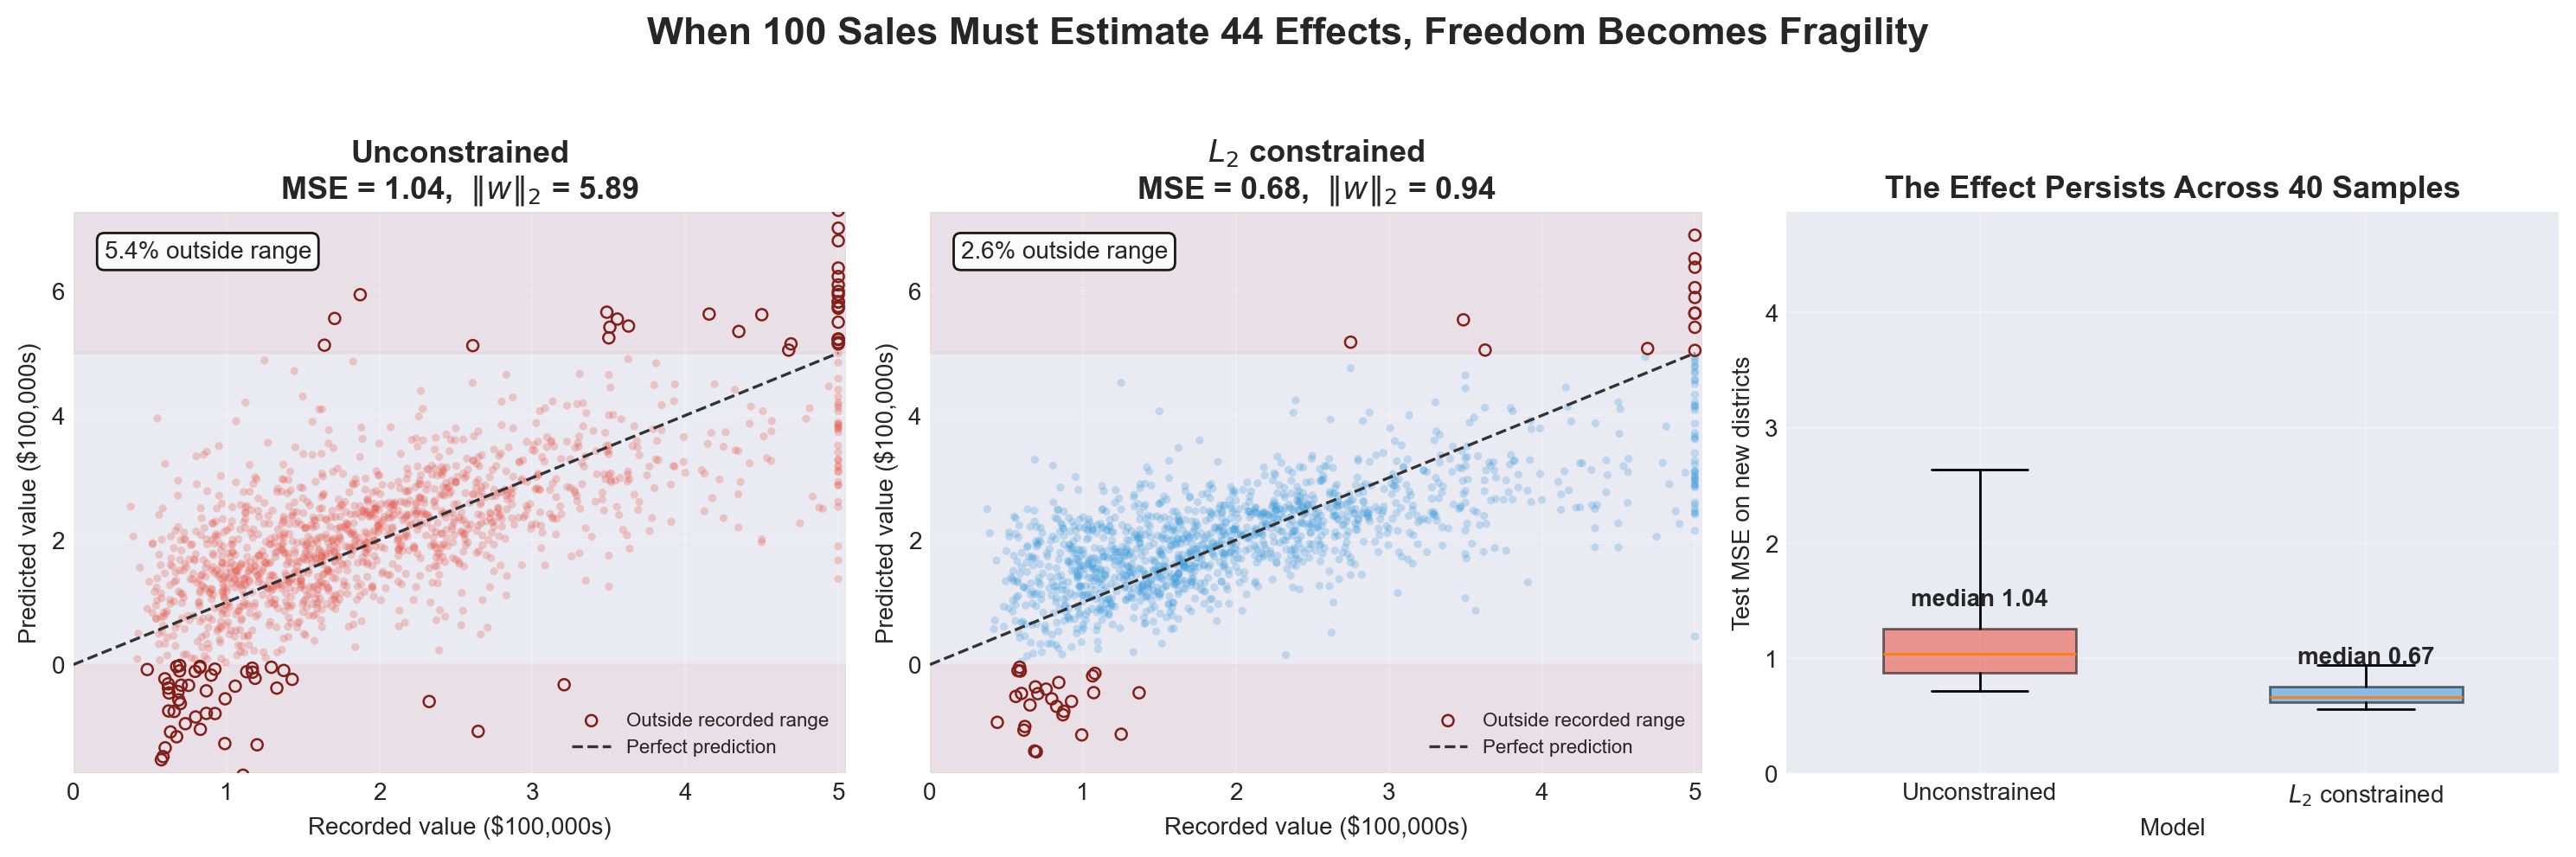

Constraint improves test MSE in 100% of repeated samples.


In [33]:
def appraisal_pipeline(estimator):
    return make_pipeline(
        StandardScaler(),
        PolynomialFeatures(2, include_bias=False),
        StandardScaler(),
        estimator,
    )

# Remove a few extreme ratio records so the experiment isolates model
# flexibility and data scarcity rather than a handful of data-quality outliers.
housing_X = housing.data
central_rows = ((housing_X[:, 0] < 10) & (housing_X[:, 2] < 10)
                & (housing_X[:, 3] < 2) & (housing_X[:, 5] < 6))
X_pool, X_test, y_pool, y_test = train_test_split(
    housing_X[central_rows], housing.target[central_rows],
    test_size=4_000, random_state=2026,
)

constraint_rng = np.random.default_rng(77)
constraint_trials = []
constraint_alphas = np.logspace(-4, 5, 40)

for _ in range(40):
    training_rows = constraint_rng.choice(len(X_pool), 100, replace=False)
    unconstrained = appraisal_pipeline(LinearRegression())
    norm_limited = appraisal_pipeline(RidgeCV(alphas=constraint_alphas))
    unconstrained.fit(X_pool[training_rows], y_pool[training_rows])
    norm_limited.fit(X_pool[training_rows], y_pool[training_rows])
    prediction_free = unconstrained.predict(X_test)
    prediction_limited = norm_limited.predict(X_test)
    constraint_trials.append({
        'rows': training_rows,
        'mse_free': mean_squared_error(y_test, prediction_free),
        'mse_limited': mean_squared_error(y_test, prediction_limited),
        'norm_free': np.linalg.norm(unconstrained[-1].coef_),
        'norm_limited': np.linalg.norm(norm_limited[-1].coef_),
        'outside_free': np.mean((prediction_free < 0) | (prediction_free > 5)),
        'outside_limited': np.mean((prediction_limited < 0) | (prediction_limited > 5)),
    })

trial_results = pd.DataFrame(constraint_trials)
target_mse = trial_results[['mse_free', 'mse_limited']].median().to_numpy()
representative_index = np.argmin(np.linalg.norm(
    (trial_results[['mse_free', 'mse_limited']].to_numpy() - target_mse)
    / target_mse, axis=1,
))
representative_rows = constraint_trials[representative_index]['rows']

unconstrained = appraisal_pipeline(LinearRegression()).fit(
    X_pool[representative_rows], y_pool[representative_rows])
norm_limited = appraisal_pipeline(RidgeCV(alphas=constraint_alphas)).fit(
    X_pool[representative_rows], y_pool[representative_rows])
representative_predictions = {
    'Unconstrained': unconstrained.predict(X_test),
    r'$L_2$ constrained': norm_limited.predict(X_test),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
display_rows = np.random.default_rng(3).choice(len(y_test), 1_400, replace=False)
panel_colors = [COLORS['current'], COLORS['optimum']]
all_predictions = np.concatenate(list(representative_predictions.values()))
prediction_limits = (min(-0.4, np.quantile(all_predictions, 0.002)),
                     max(5.4, np.quantile(all_predictions, 0.998)))

for ax, (label, predictions), color in zip(
        axes[:2], representative_predictions.items(), panel_colors):
    shown_predictions = predictions[display_rows]
    shown_targets = y_test[display_rows]
    outside = (shown_predictions < 0) | (shown_predictions > 5)
    ax.scatter(shown_targets[~outside], shown_predictions[~outside],
               s=11, alpha=0.25, color=color, edgecolor='none')
    ax.scatter(shown_targets[outside], shown_predictions[outside],
               s=22, facecolor='none', edgecolor='#7d1d16', linewidth=0.9,
               label='Outside recorded range')
    ax.plot([0, 5], [0, 5], color='#333333', linestyle='--', linewidth=1.2,
            label='Perfect prediction')
    ax.axhspan(prediction_limits[0], 0, color=COLORS['current'], alpha=0.06)
    ax.axhspan(5, prediction_limits[1], color=COLORS['current'], alpha=0.06)
    model = unconstrained if label == 'Unconstrained' else norm_limited
    mse = mean_squared_error(y_test, predictions)
    outside_rate = np.mean((predictions < 0) | (predictions > 5))
    panel_title = (f'{label}\nMSE = {mse:.2f},  '
                   + rf'$\Vert w\Vert_2$ = {np.linalg.norm(model[-1].coef_):.2f}')
    style_plot(ax, panel_title,
               'Recorded value ($100,000s)', 'Predicted value ($100,000s)')
    ax.set_xlim(0, 5.05)
    ax.set_ylim(*prediction_limits)
    ax.text(0.04, 0.95, f'{outside_rate:.1%} outside range',
            transform=ax.transAxes, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
    ax.legend(loc='lower right', fontsize=8)

box = axes[2].boxplot(
    [trial_results['mse_free'], trial_results['mse_limited']],
    positions=[1, 2], widths=0.5, whis=(5, 95), showfliers=False,
    patch_artist=True,
)
for patch, color in zip(box['boxes'], panel_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)
axes[2].set_xticks([1, 2])
axes[2].set_xticklabels(['Unconstrained', r'$L_2$ constrained'])
style_plot(axes[2], 'The Effect Persists Across 40 Samples',
           'Model', 'Test MSE on new districts')
axes[2].set_ylim(0, trial_results['mse_free'].quantile(0.98) * 1.08)
for position, column in [(1, 'mse_free'), (2, 'mse_limited')]:
    median = trial_results[column].median()
    label_height = trial_results[column].quantile(0.75) + 0.15
    axes[2].text(position, label_height, f'median {median:.2f}',
                 ha='center', va='bottom', fontweight='bold')

fig.suptitle('When 100 Sales Must Estimate 44 Effects, Freedom Becomes Fragility',
             fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

win_rate = np.mean(trial_results['mse_limited'] < trial_results['mse_free'])
print(f'Constraint improves test MSE in {win_rate:.0%} of repeated samples.')

## Part 2: From Manual Search to a Gradient Step

A line is controlled by two parameters. Move the weight and bias sliders to search manually, then change the learning rate to preview the exact step gradient descent would take. The two panels show the **same model state in two spaces**: a line in data space and a point in parameter space.


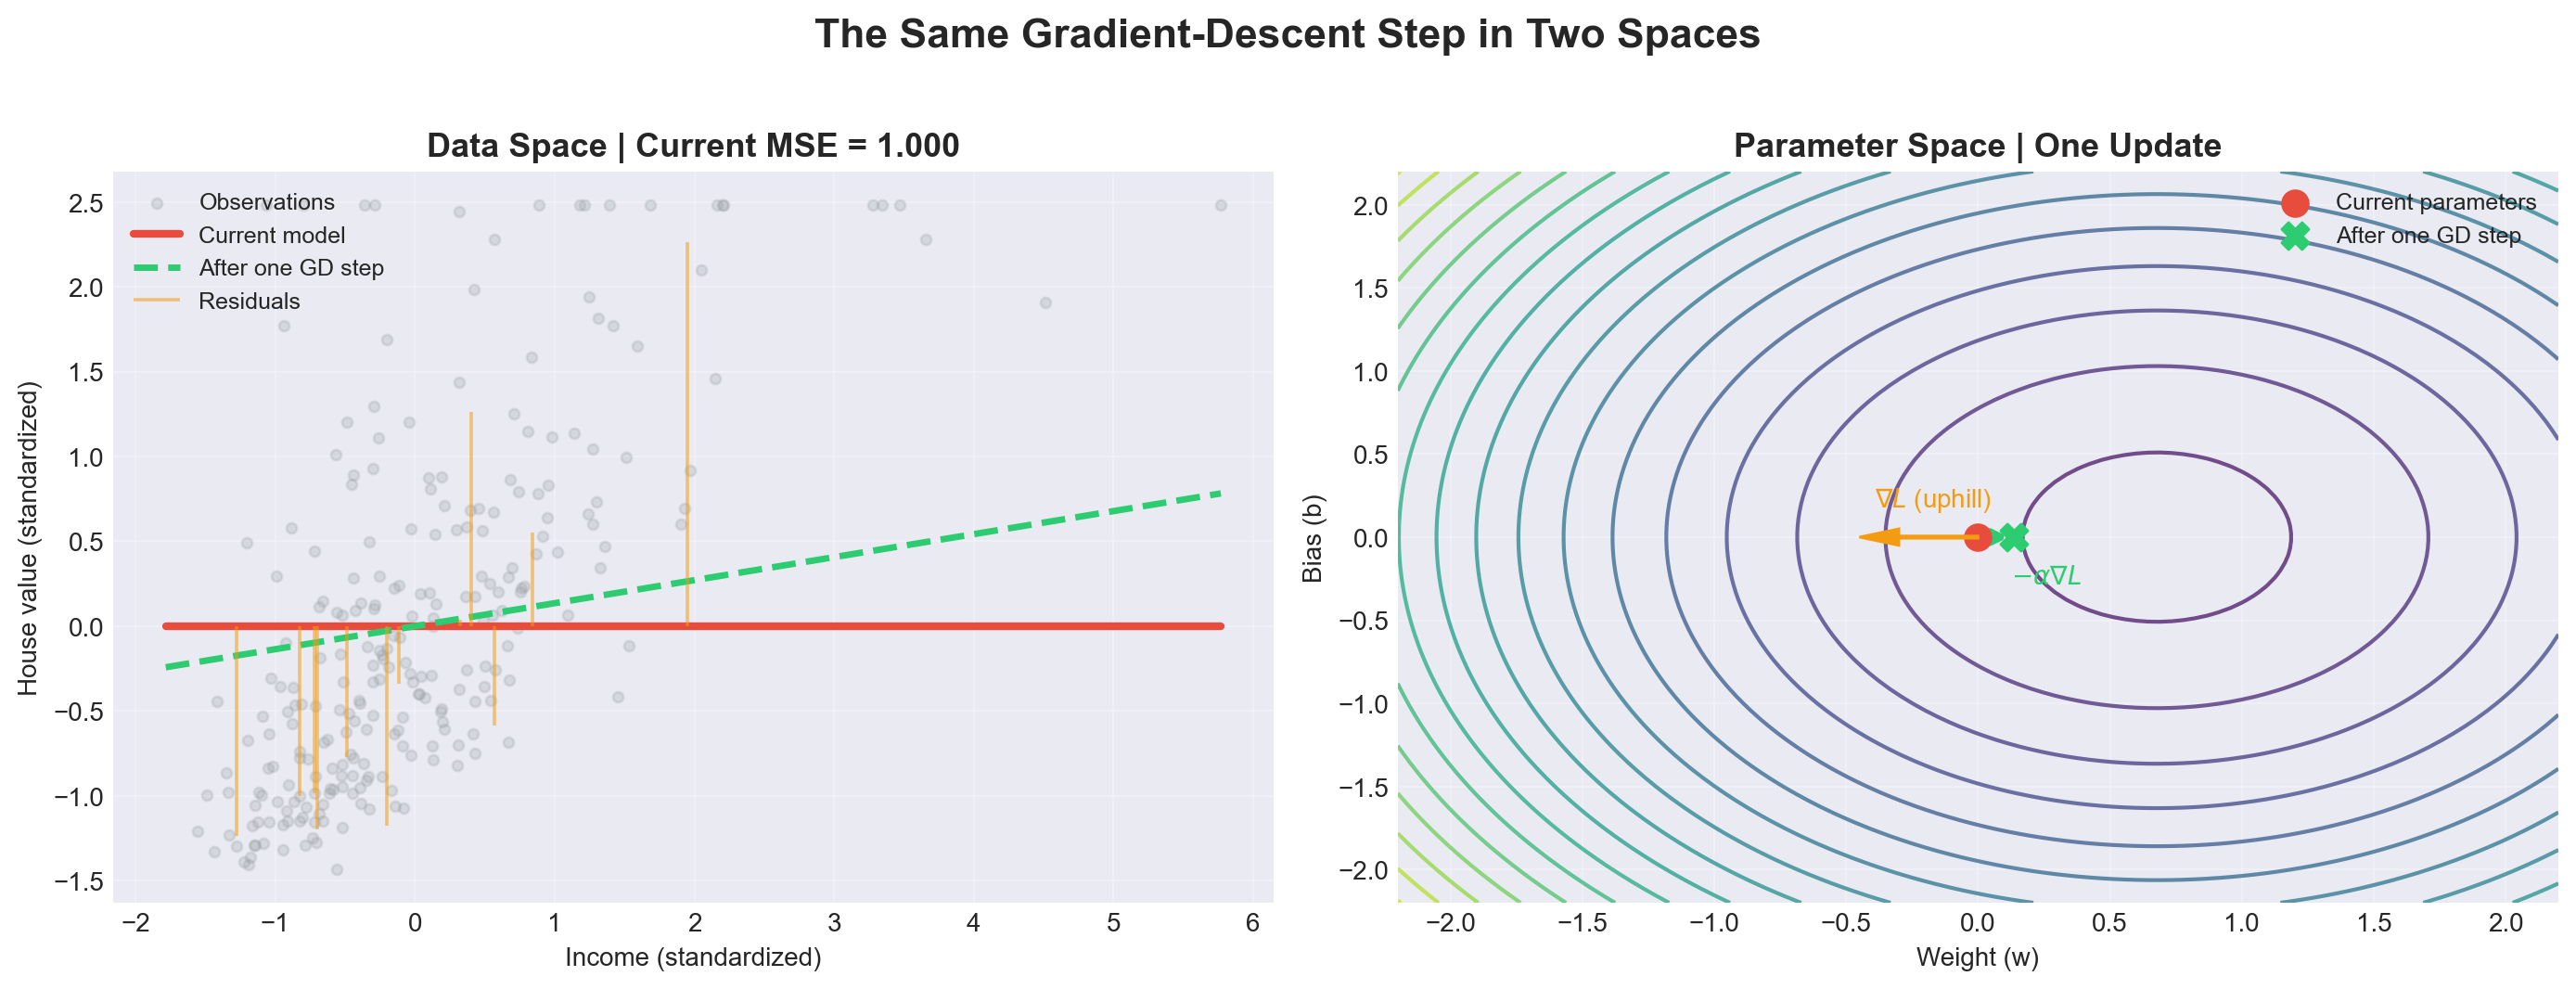

Gradient: ∂L/∂w=-1.356, ∂L/∂b=-0.000
One step: (+0.000, +0.000) → (+0.136, +0.000)
Loss: 1.0000 → 0.8345


interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='Weight w:', max=2.0, min=-2…

In [5]:
# Standardize only where it becomes useful: in the linked parameter-space view,
# comparable scales make one learning rate meaningful for both weight and bias.
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X = scaler_X.fit_transform(X_raw.reshape(-1, 1)).ravel()
y = scaler_y.fit_transform(y_raw.reshape(-1, 1)).ravel()

def mse_loss(w, b, X=X, y=y):
    return np.mean((w * X + b - y) ** 2)

def mse_gradient(w, b, X=X, y=y):
    errors = w * X + b - y
    return np.array([2 * np.mean(X * errors), 2 * np.mean(errors)])

# Exact least-squares solution, used only as a reference marker.
design = np.column_stack([X, np.ones_like(X)])
optimal_w, optimal_b = np.linalg.lstsq(design, y, rcond=None)[0]

w_values = np.linspace(-2.2, 2.2, 100)
b_values = np.linspace(-2.2, 2.2, 100)
weight_mesh, bias_mesh = np.meshgrid(w_values, b_values)
# MSE is quadratic in (w, b), so six dataset moments define the full surface.
# This is identical to predicting at every grid point but avoids a large 3D tensor.
loss_surface = (weight_mesh**2 * np.mean(X**2)
                + 2 * weight_mesh * bias_mesh * np.mean(X)
                + bias_mesh**2
                - 2 * weight_mesh * np.mean(X * y)
                - 2 * bias_mesh * np.mean(y)
                + np.mean(y**2))

def visualize_linked_step(w=0.0, b=0.0, learning_rate=0.10, show_optimum=False):
    gradient = mse_gradient(w, b)
    next_w, next_b = np.array([w, b]) - learning_rate * gradient
    current_loss = mse_loss(w, b)
    next_loss = mse_loss(next_w, next_b)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

    # Left: the model in data space.
    shown = np.arange(0, len(X), 8)
    axes[0].scatter(X[shown], y[shown], s=16, alpha=0.25,
                    color=COLORS['data'], label='Observations')
    x_line = np.linspace(X.min(), X.max(), 200)
    axes[0].plot(x_line, w * x_line + b, color=COLORS['current'],
                 linewidth=3, label='Current model')
    axes[0].plot(x_line, next_w * x_line + next_b, color=COLORS['step'],
                 linewidth=2.5, linestyle='--', label='After one GD step')

    residual_idx = np.linspace(0, len(X) - 1, 12, dtype=int)
    axes[0].vlines(X[residual_idx], y[residual_idx],
                   w * X[residual_idx] + b,
                   color=COLORS['gradient'], alpha=0.55, linewidth=1.3,
                   label='Residuals')
    if show_optimum:
        axes[0].plot(x_line, optimal_w * x_line + optimal_b,
                     color=COLORS['optimum'], linewidth=2, linestyle=':',
                     label='Optimal line')
    style_plot(axes[0], f'Data Space | Current MSE = {current_loss:.3f}',
               'Income (standardized)', 'House value (standardized)')
    axes[0].legend(loc='upper left', fontsize=9)

    # Keep both endpoints visible when a large learning rate overshoots.
    view_limit = max(2.2, 1.12 * np.max(np.abs([w, b, next_w, next_b])))
    view_values = np.linspace(-view_limit, view_limit, 100)
    view_w, view_b = np.meshgrid(view_values, view_values)
    view_loss = (view_w**2 * np.mean(X**2)
                 + 2 * view_w * view_b * np.mean(X) + view_b**2
                 - 2 * view_w * np.mean(X * y)
                 - 2 * view_b * np.mean(y) + np.mean(y**2))

    # Right: the same model in parameter space.
    axes[1].contour(view_w, view_b, view_loss,
                    levels=18, cmap='viridis', alpha=0.75)
    axes[1].scatter(w, b, color=COLORS['current'], s=100, zorder=5,
                    label='Current parameters')
    axes[1].scatter(next_w, next_b, color=COLORS['step'], s=110, marker='X',
                    zorder=6, label='After one GD step')

    # The orange arrow points uphill; the green arrow is the actual update.
    grad_norm = np.linalg.norm(gradient)
    if grad_norm > 1e-10:
        display_gradient = 0.45 * gradient / grad_norm
        axes[1].arrow(w, b, display_gradient[0], display_gradient[1],
                      color=COLORS['gradient'], width=0.014,
                      head_width=0.10, length_includes_head=True, zorder=5)
        axes[1].annotate(r'$\nabla L$ (uphill)',
                         xy=(w + display_gradient[0],
                             b + display_gradient[1]),
                         xytext=(6, 12), textcoords='offset points',
                         color=COLORS['gradient'], fontsize=10)
    axes[1].annotate('', xy=(next_w, next_b), xytext=(w, b),
                     arrowprops=dict(arrowstyle='->', color=COLORS['step'],
                                     linewidth=3))
    midpoint = (np.array([w, b]) + np.array([next_w, next_b])) / 2
    axes[1].annotate(r'$-\alpha\nabla L$', xy=midpoint,
                     xytext=(6, -18), textcoords='offset points',
                     color=COLORS['step'], fontsize=10, fontweight='bold')

    if show_optimum:
        axes[1].scatter(optimal_w, optimal_b, color=COLORS['optimum'],
                        s=170, marker='*', zorder=6, label='Global minimum')
    style_plot(axes[1], 'Parameter Space | One Update', 'Weight (w)', 'Bias (b)')
    axes[1].set_xlim(-view_limit, view_limit)
    axes[1].set_ylim(-view_limit, view_limit)
    axes[1].legend(loc='upper right', fontsize=9)

    fig.suptitle('The Same Gradient-Descent Step in Two Spaces',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    print(f'Gradient: ∂L/∂w={gradient[0]:+.3f}, ∂L/∂b={gradient[1]:+.3f}')
    print(f'One step: ({w:+.3f}, {b:+.3f}) → ({next_w:+.3f}, {next_b:+.3f})')
    print(f'Loss: {current_loss:.4f} → {next_loss:.4f}')

visualize_linked_step()

_ = widgets.interact_manual.options(manual_name='Update linked view')(
    visualize_linked_step,
    w=widgets.FloatSlider(value=0.0, min=-2.0, max=2.0, step=0.05,
                          description='Weight w:', continuous_update=False),
    b=widgets.FloatSlider(value=0.0, min=-2.0, max=2.0, step=0.05,
                          description='Bias b:', continuous_update=False),
    learning_rate=widgets.FloatLogSlider(value=0.10, base=10,
                                          min=-3, max=0.08, step=0.05,
                                          description='Learning rate α:',
                                          continuous_update=False),
    show_optimum=widgets.Checkbox(value=False, description='Show optimum'),
)

## Part 3: Where the Gradient Comes From

For $\hat y_i=wx_i+b$ and

$$L(w,b)=\frac{1}{n}\sum_i(\hat y_i-y_i)^2,$$

the derivatives are

$$\frac{\partial L}{\partial w}=\frac{2}{n}\sum_i x_i(\hat y_i-y_i),\qquad
\frac{\partial L}{\partial b}=\frac{2}{n}\sum_i(\hat y_i-y_i).$$

The gradient points toward the steepest local increase. Gradient descent moves in the opposite direction:

$$\begin{bmatrix}w\\b\end{bmatrix}_{t+1}
=\begin{bmatrix}w\\b\end{bmatrix}_{t}-\alpha\nabla L(w_t,b_t).$$


In [35]:
def run_gradient_descent(X, y, learning_rate=0.10, steps=50, w0=0.0, b0=0.0):
    # Plain full-batch gradient descent—no clipping or hidden safeguards.
    w, b = float(w0), float(b0)
    history = {'w': [], 'b': [], 'loss': [], 'gradient_norm': []}

    for step in range(steps + 1):
        errors = w * X + b - y
        grad_w = 2 * np.mean(X * errors)
        grad_b = 2 * np.mean(errors)

        history['w'].append(w)
        history['b'].append(b)
        history['loss'].append(np.mean(errors ** 2))
        history['gradient_norm'].append(np.hypot(grad_w, grad_b))

        w -= learning_rate * grad_w
        b -= learning_rate * grad_b

    return {name: np.asarray(values) for name, values in history.items()}

gd_history = run_gradient_descent(X, y, learning_rate=0.10, steps=40)
print(f"Final parameters: w={gd_history['w'][-1]:.4f}, b={gd_history['b'][-1]:.4f}")
print(f"Final loss: {gd_history['loss'][-1]:.4f}")

Final parameters: w=0.6779, b=0.0000
Final loss: 0.5404


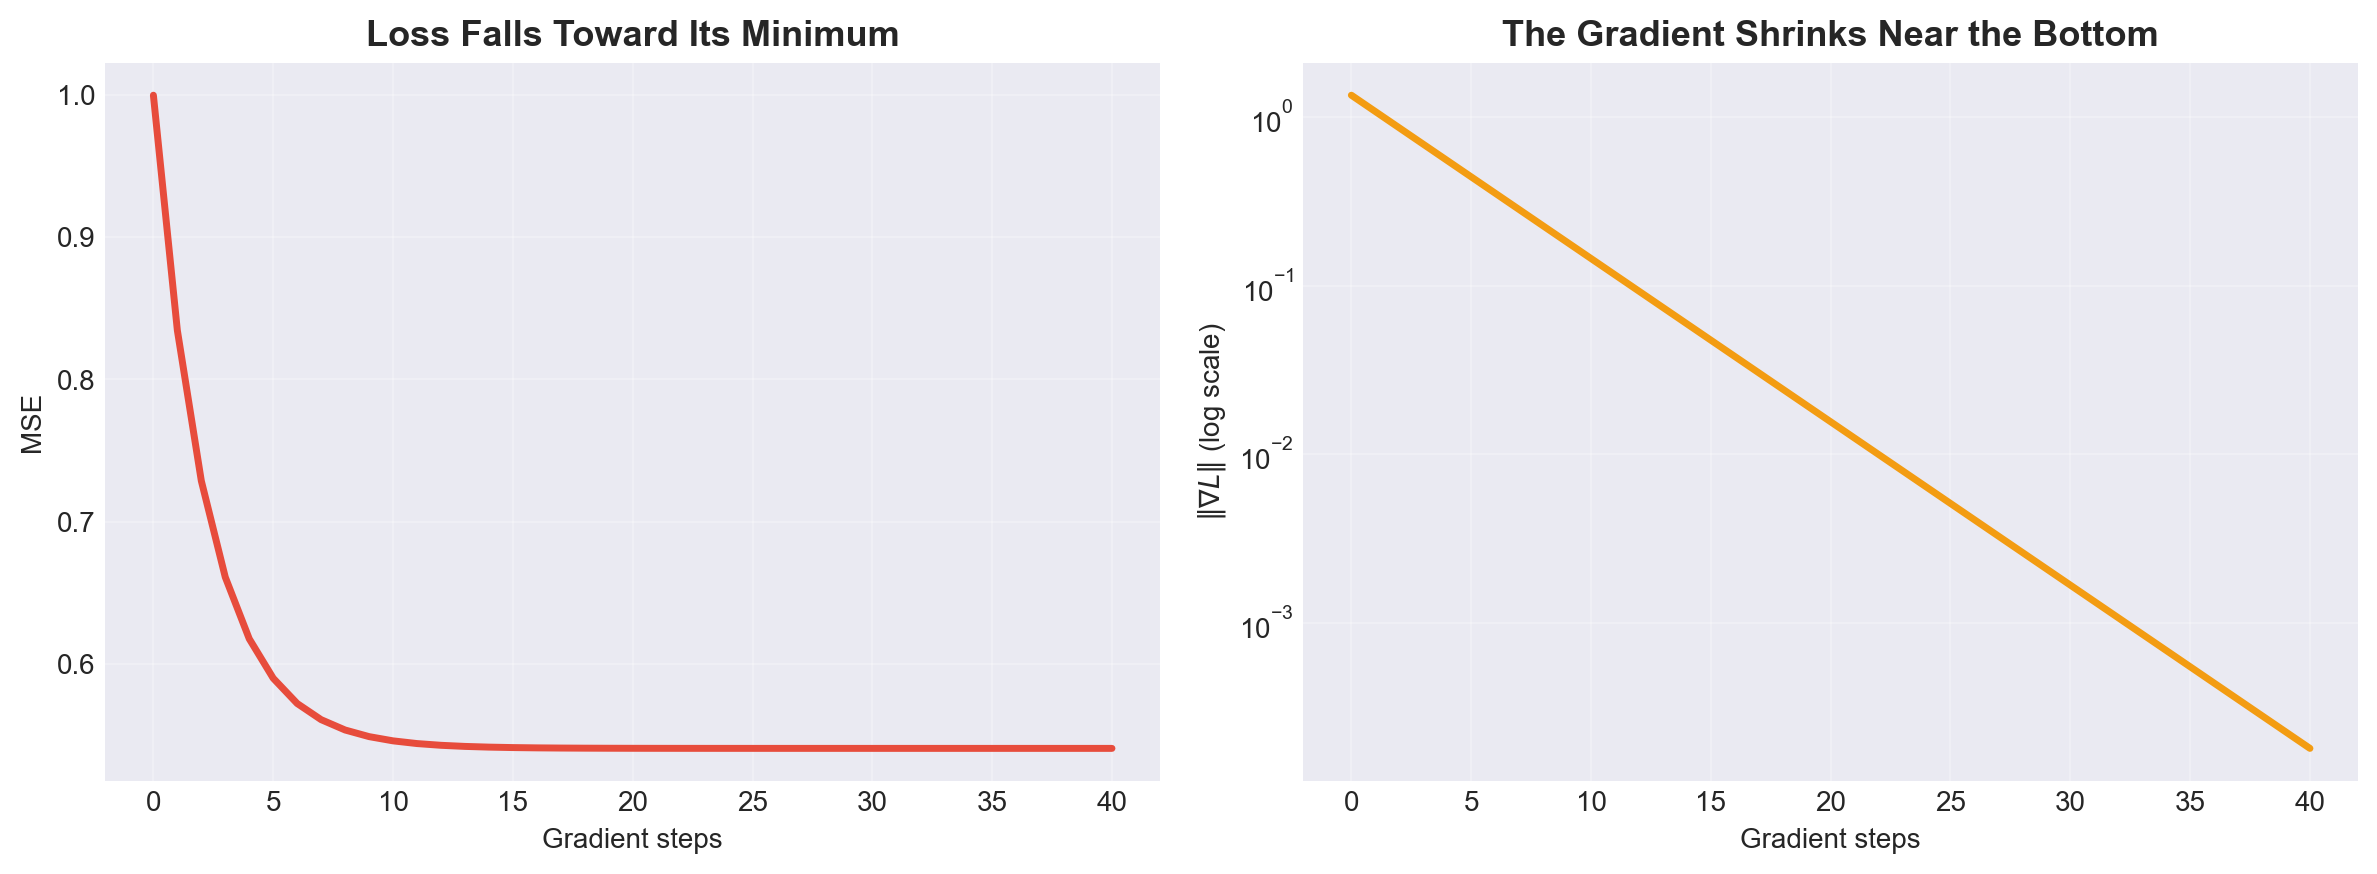

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(gd_history['loss'], color=COLORS['current'], linewidth=2.5)
style_plot(axes[0], 'Loss Falls Toward Its Minimum', 'Gradient steps', 'MSE')

axes[1].semilogy(gd_history['gradient_norm'],
                 color=COLORS['gradient'], linewidth=2.5)
style_plot(axes[1], 'The Gradient Shrinks Near the Bottom',
           'Gradient steps', r'$\|\nabla L\|$ (log scale)')

plt.tight_layout()
plt.show()

## Part 4: Learning Rate Controls the Step

The learning rate $\alpha$ multiplies the gradient. Too small wastes steps; a useful rate converges quickly; too large repeatedly overshoots and can diverge. The three panels use the same data, initialization, and number of updates.


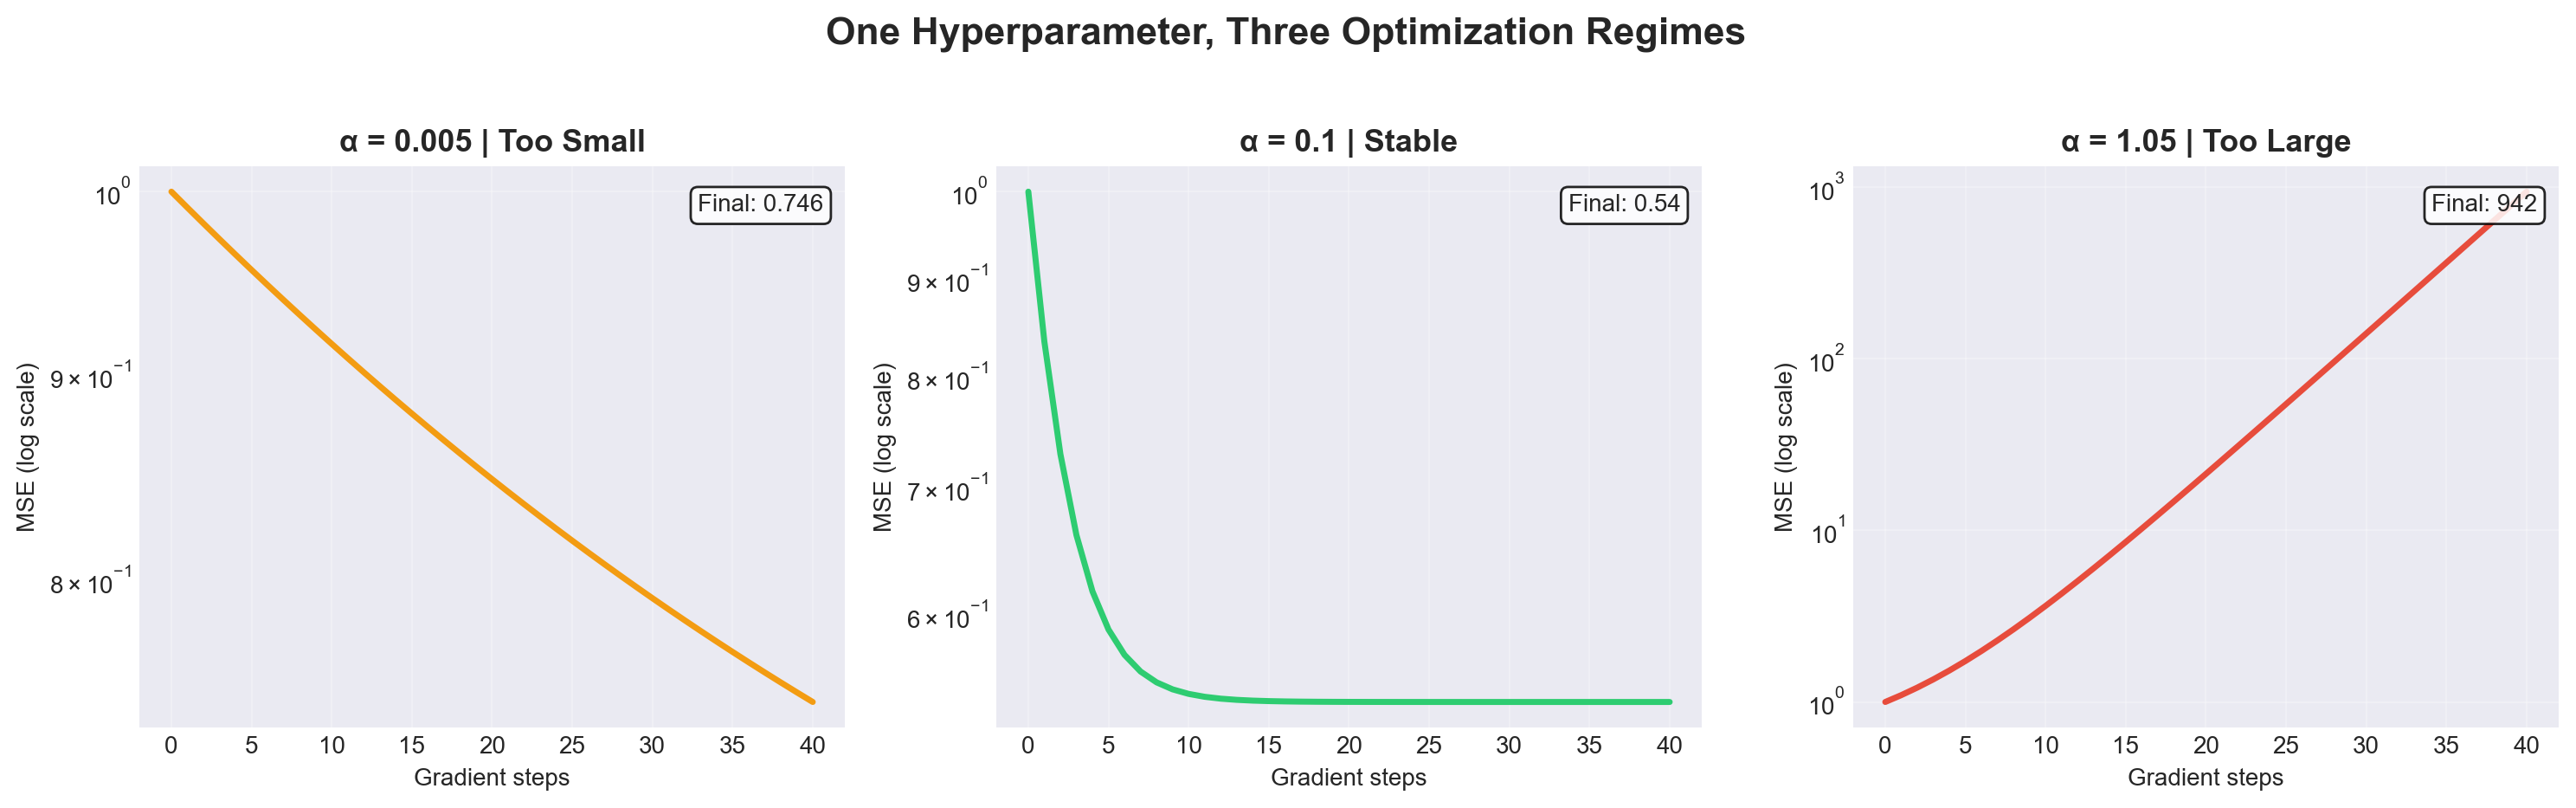

In [37]:
learning_rate_cases = [
    (0.005, 'Too Small'),
    (0.10, 'Stable'),
    (1.05, 'Too Large'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True)
for ax, (learning_rate, label) in zip(axes, learning_rate_cases):
    history = run_gradient_descent(X, y, learning_rate=learning_rate, steps=40)
    color = {'Too Small': COLORS['gradient'],
             'Stable': COLORS['step'],
             'Too Large': COLORS['current']}[label]
    ax.semilogy(history['loss'], color=color, linewidth=2.5)
    style_plot(ax, f'α = {learning_rate:g} | {label}', 'Gradient steps', 'MSE (log scale)')
    ax.text(0.97, 0.95, f"Final: {history['loss'][-1]:.3g}",
            transform=ax.transAxes, ha='right', va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

fig.suptitle('One Hyperparameter, Three Optimization Regimes',
             fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## Part 5: Feature Scale Changes the Geometry

With multiple features, unequal scales stretch the loss contours into a narrow valley. A single scalar learning rate must remain stable across the steep direction, so progress along the flat direction becomes slow. Standardization is a change of coordinates that usually improves this conditioning.


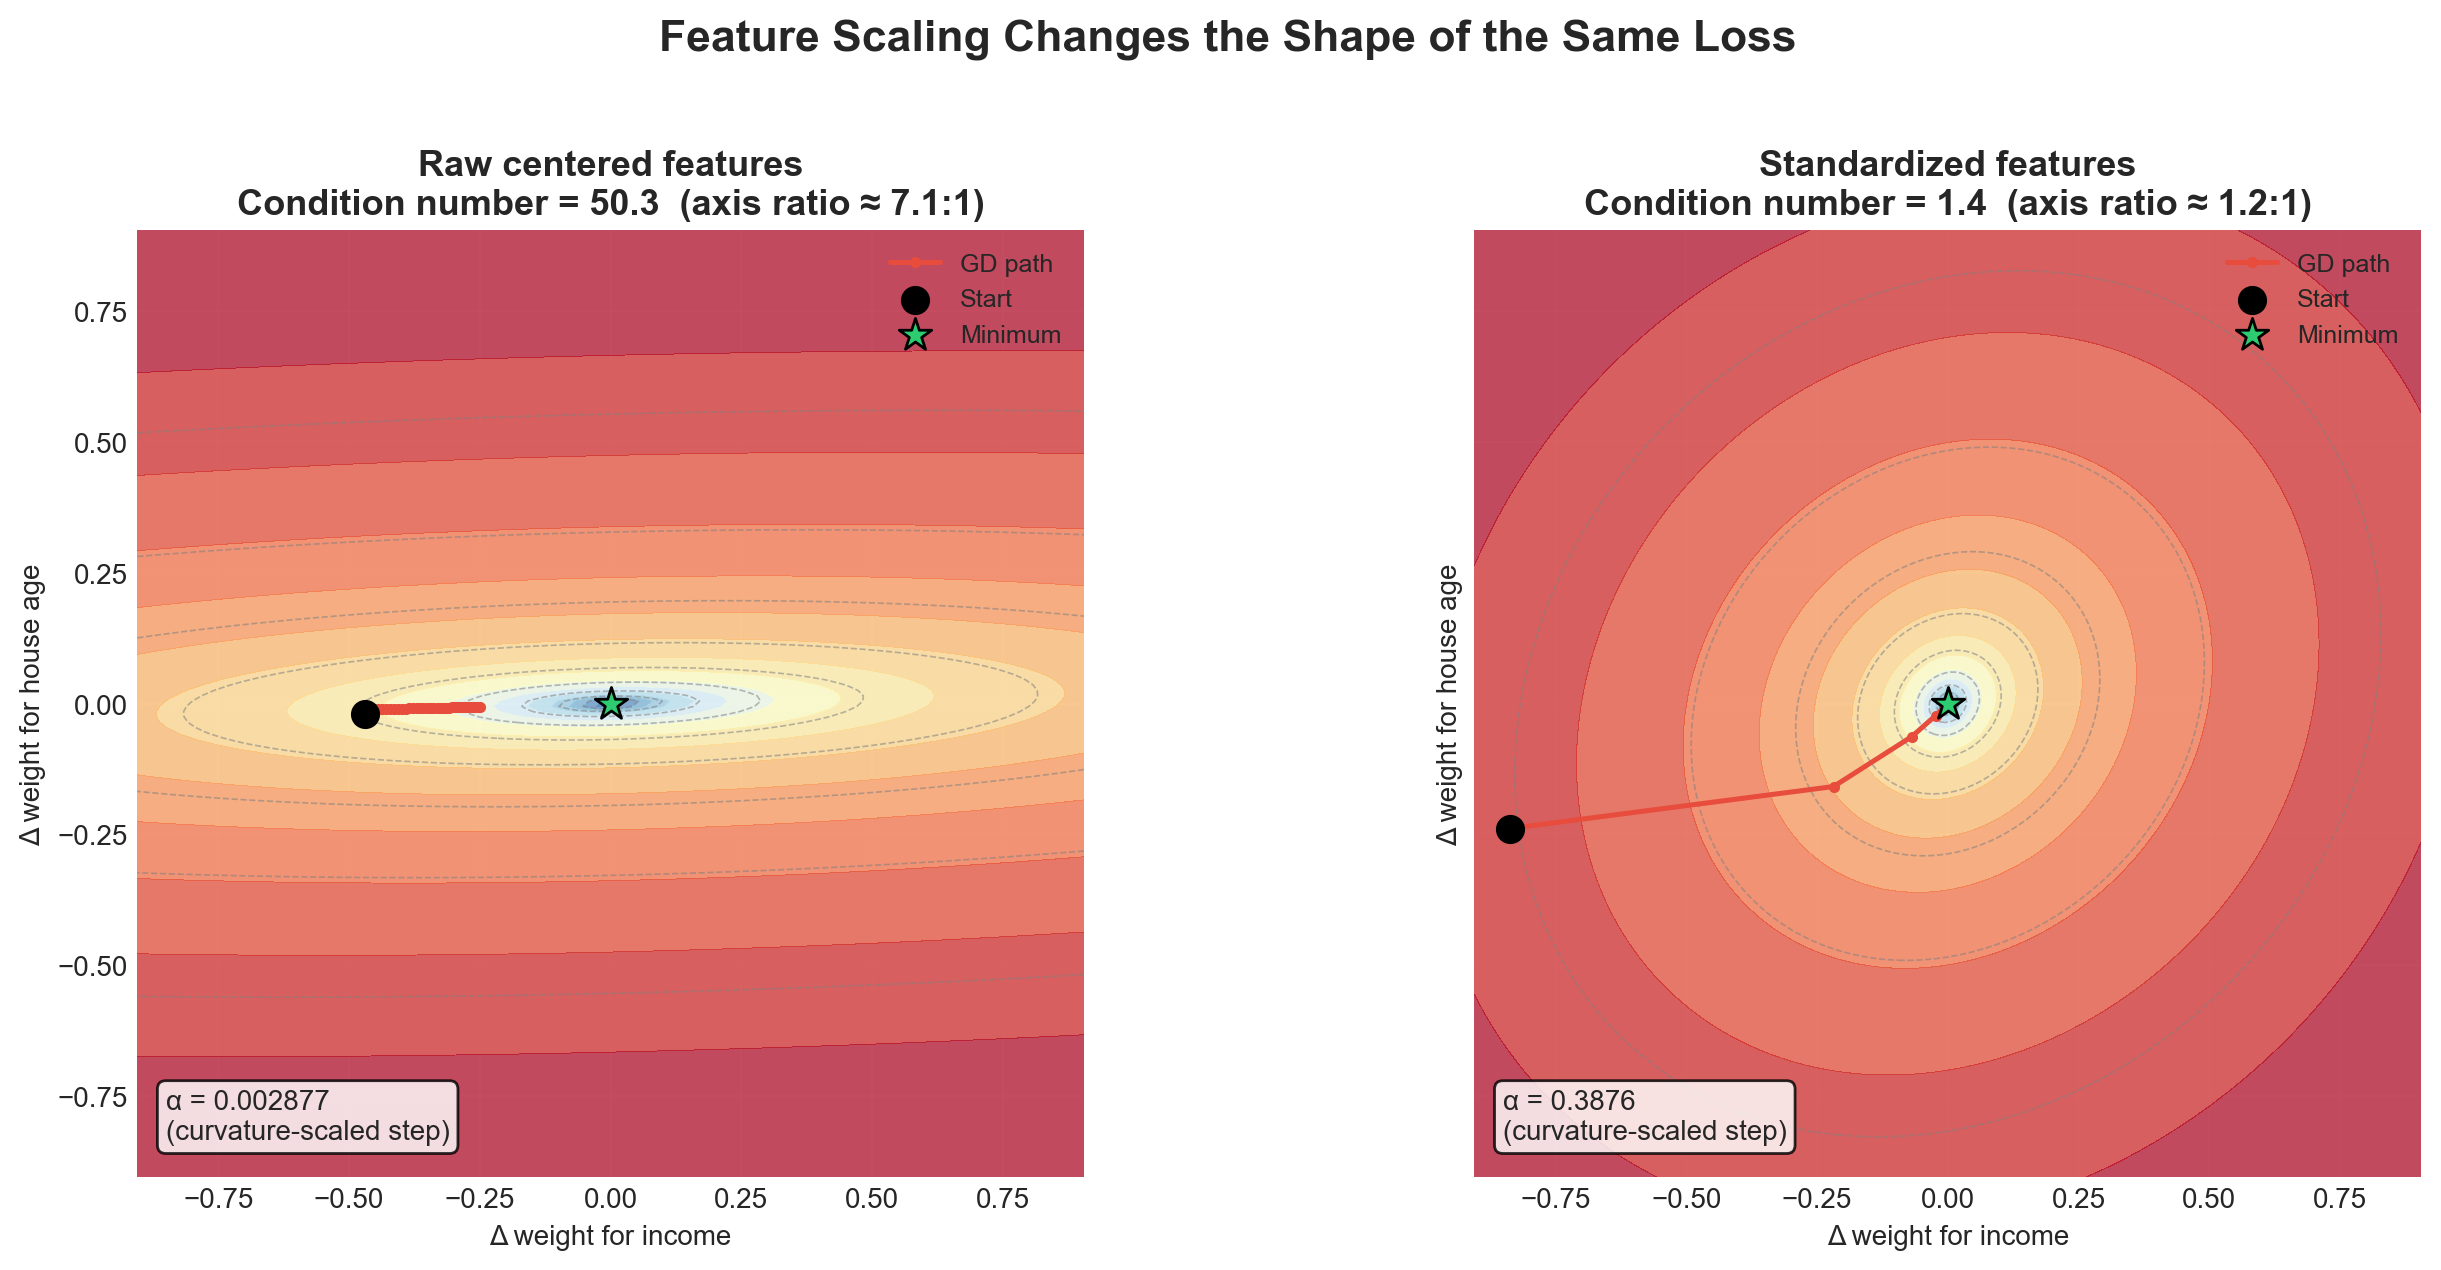

In [38]:
two_feature_indices = sample_indices[:500]
X_two_raw = df.loc[two_feature_indices, ['MedInc', 'HouseAge']].to_numpy()
y_two = df.loc[two_feature_indices, 'target'].to_numpy()

# Center both versions so an omitted intercept does not confound the comparison.
X_centered = X_two_raw - X_two_raw.mean(axis=0)
y_centered = y_two - y_two.mean()
X_scaled = X_centered / X_centered.std(axis=0)

def gd_path_2d(X_design, y_target, steps=35):
    hessian = 2 * (X_design.T @ X_design) / len(X_design)
    # Scale the step to each coordinate system's steepest curvature.
    learning_rate = 0.9 / np.linalg.eigvalsh(hessian).max()
    weights = np.zeros(2)
    path = [weights.copy()]
    for _ in range(steps):
        gradient = 2 * X_design.T @ (X_design @ weights - y_target) / len(X_design)
        weights -= learning_rate * gradient
        path.append(weights.copy())
    return np.asarray(path), learning_rate, np.linalg.cond(hessian)

def excess_loss_grid_2d(X_design, weight_1_mesh, weight_2_mesh):
    gram = X_design.T @ X_design / len(X_design)
    return (gram[0, 0] * weight_1_mesh**2
            + 2 * gram[0, 1] * weight_1_mesh * weight_2_mesh
            + gram[1, 1] * weight_2_mesh**2)

cases = [
    ('Raw centered features', X_centered),
    ('Standardized features', X_scaled),
]

case_results = []
for title, X_design in cases:
    path, learning_rate, condition = gd_path_2d(X_design, y_centered)
    optimum = np.linalg.lstsq(X_design, y_centered, rcond=None)[0]
    case_results.append((title, X_design, path, learning_rate,
                         condition, optimum))

# Align both minima at the origin, then use one square window and equal data
# aspect. This makes ellipse shape—not plot stretching—the visual comparison.
relative_paths = [
    path - optimum
    for _, _, path, _, _, optimum in case_results
]
radius = 1.08 * max(np.abs(path).max() for path in relative_paths)
weight_1_values = np.linspace(-radius, radius, 180)
weight_2_values = np.linspace(-radius, radius, 180)
weight_1_mesh, weight_2_mesh = np.meshgrid(weight_1_values, weight_2_values)

fig, axes = plt.subplots(1, 2, figsize=(14, 6.2), sharex=True, sharey=True)
for ax, (title, X_design, path, learning_rate,
         condition, optimum) in zip(axes, case_results):
    relative_path = path - optimum
    excess = excess_loss_grid_2d(
        X_design, weight_1_mesh, weight_2_mesh)
    excess = np.maximum(excess, 1e-8)
    relative_log_loss = np.log10(excess / excess.max())

    ax.contourf(weight_1_mesh, weight_2_mesh, relative_log_loss,
                levels=np.linspace(-5, 0, 18),
                cmap='RdYlBu_r', alpha=0.72)
    ax.contour(weight_1_mesh, weight_2_mesh, relative_log_loss,
               levels=np.linspace(-5, 0, 12),
               colors='gray', linewidths=0.6, alpha=0.55)
    ax.plot(relative_path[:, 0], relative_path[:, 1], color=COLORS['current'],
            marker='o', markersize=3, linewidth=1.8, label='GD path')
    ax.scatter(relative_path[0, 0], relative_path[0, 1], s=90, color='black',
               zorder=5, label='Start')
    ax.scatter(0, 0, s=150, marker='*',
               color=COLORS['step'], edgecolor='black', zorder=6,
               label='Minimum')
    style_plot(ax, (f'{title}\nCondition number = {condition:.1f}  '
                    f'(axis ratio ≈ {np.sqrt(condition):.1f}:1)'),
               'Δ weight for income', 'Δ weight for house age')
    ax.text(0.03, 0.04, f'α = {learning_rate:.4g}\n(curvature-scaled step)',
            transform=ax.transAxes,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.82))
    ax.legend(loc='upper right', fontsize=9)
    ax.set_xlim(-radius, radius)
    ax.set_ylim(-radius, radius)
    ax.set_aspect('equal', adjustable='box')

fig.suptitle('Feature Scaling Changes the Shape of the Same Loss',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Part 6: Batch Size Controls Gradient Noise

The full gradient is an average of per-observation gradients. Stochastic gradient descent uses one observation as a noisy estimate; a mini-batch averages several estimates; batch gradient descent averages all of them. The expectation points in the same direction, but the variance changes dramatically.

In the convergence comparison, every epoch processes all 2,000 observations once; batch GD makes one parameter update, a mini-batch of 32 makes 63, and SGD makes 2,000. This exposes the trade-off between update frequency and gradient noise.


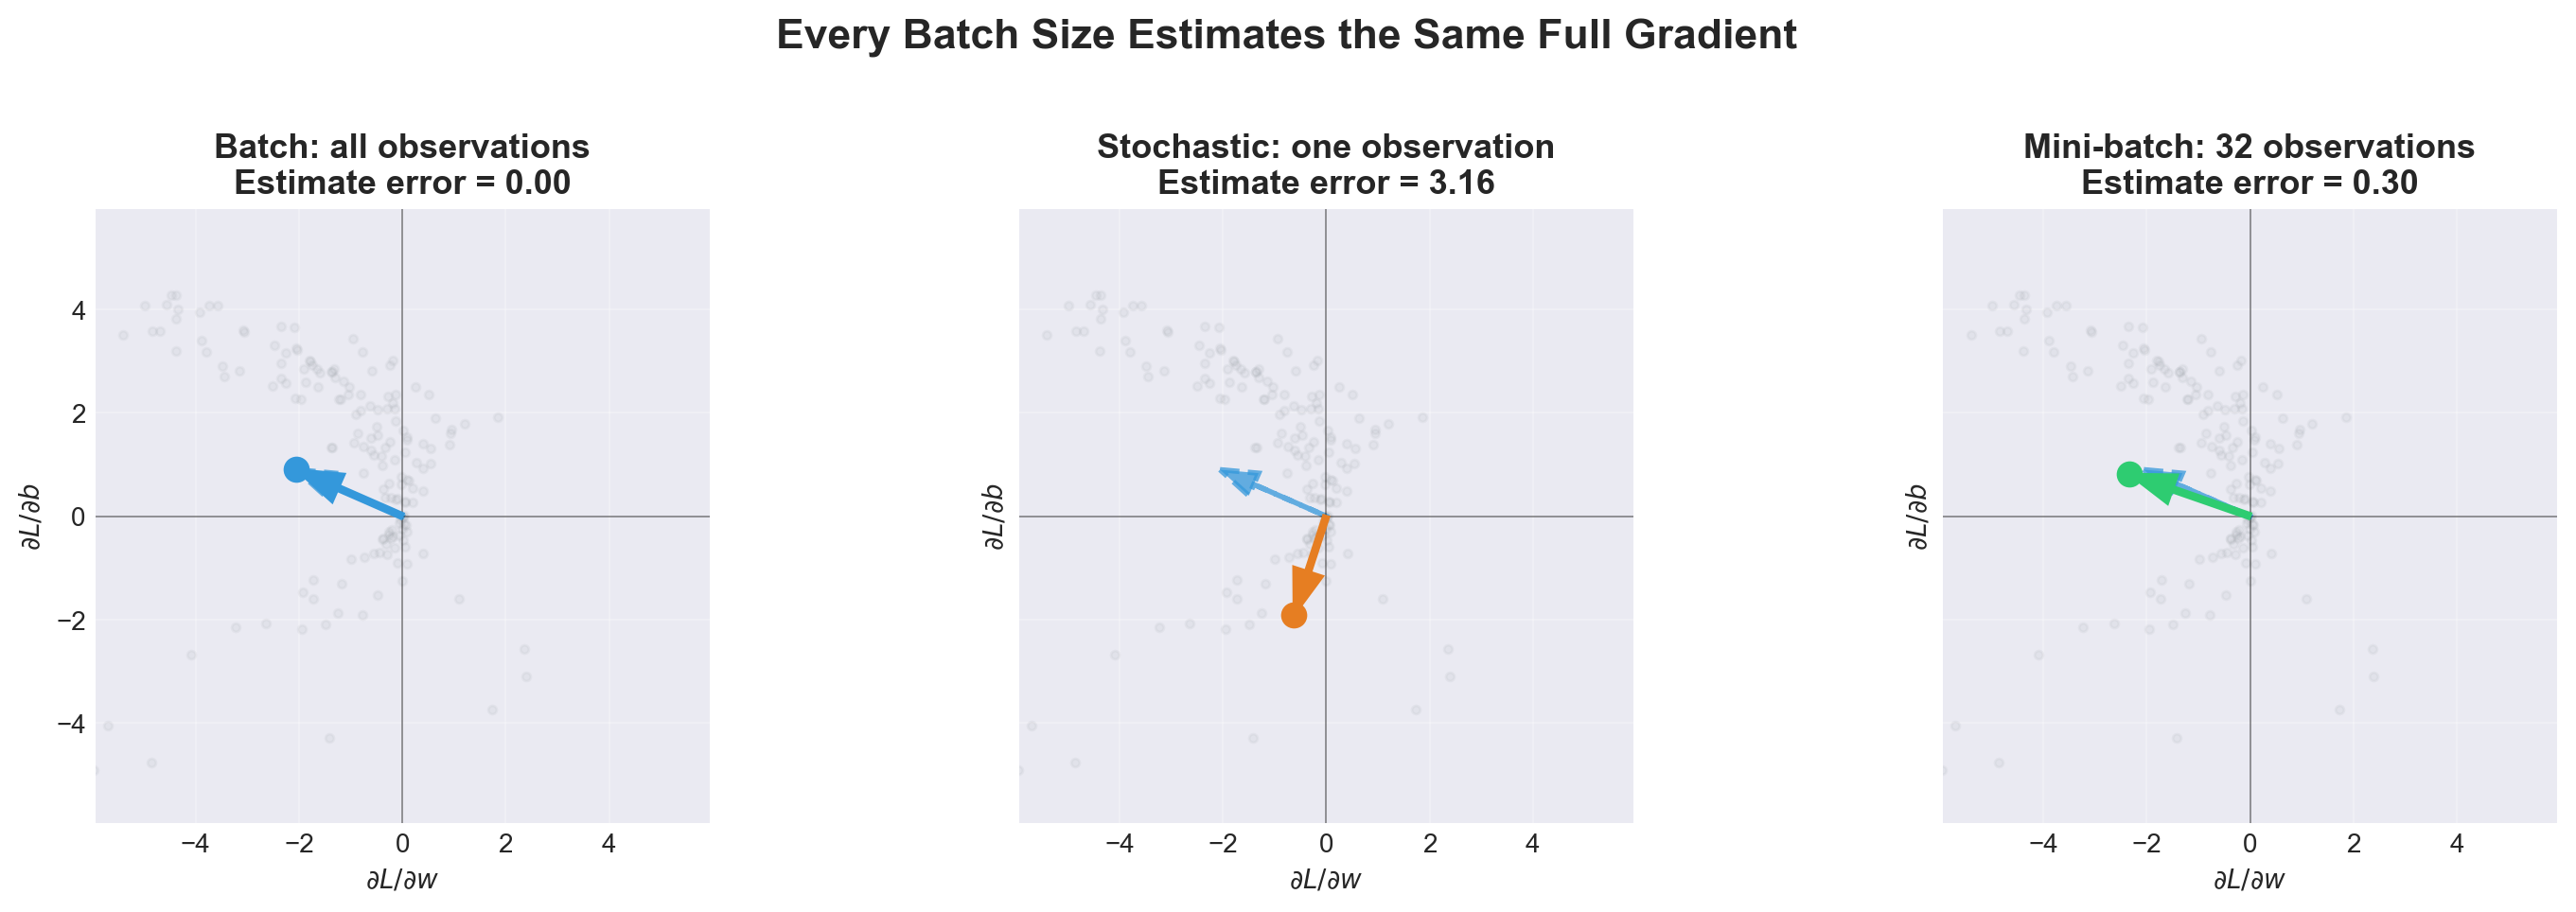

In [39]:
# Compare gradient estimates at one deliberately imperfect model.
w_demo, b_demo = -0.35, 0.45
errors = w_demo * X + b_demo - y
per_observation_gradients = np.column_stack([2 * X * errors, 2 * errors])
full_gradient = per_observation_gradients.mean(axis=0)

rng = np.random.default_rng(7)
one_index = rng.integers(len(X))
mini_indices = rng.choice(len(X), 32, replace=False)
estimates = [
    ('Batch: all observations', full_gradient, COLORS['optimum']),
    ('Stochastic: one observation', per_observation_gradients[one_index], COLORS['stochastic']),
    ('Mini-batch: 32 observations', per_observation_gradients[mini_indices].mean(axis=0), COLORS['step']),
]

selected_vectors = np.vstack([full_gradient] + [item[1] for item in estimates])
limit = max(np.quantile(np.abs(per_observation_gradients), 0.94),
            np.abs(selected_vectors).max()) * 1.15

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharex=True, sharey=True)
cloud = per_observation_gradients[rng.choice(len(X), 180, replace=False)]
for ax, (title, estimate, color) in zip(axes, estimates):
    ax.scatter(cloud[:, 0], cloud[:, 1], s=10, alpha=0.10,
               color=COLORS['data'], label='Individual gradients')
    ax.arrow(0, 0, full_gradient[0], full_gradient[1],
             color=COLORS['optimum'], linewidth=2, linestyle='--',
             head_width=0.08 * limit, length_includes_head=True,
             alpha=0.75)
    ax.arrow(0, 0, estimate[0], estimate[1], color=color,
             width=0.018 * limit, head_width=0.10 * limit,
             length_includes_head=True, zorder=5)
    ax.scatter(estimate[0], estimate[1], color=color, s=80, zorder=6)
    error_norm = np.linalg.norm(estimate - full_gradient)
    style_plot(ax, f'{title}\nEstimate error = {error_norm:.2f}',
               r'$\partial L/\partial w$', r'$\partial L/\partial b$')
    ax.axhline(0, color='black', linewidth=0.7, alpha=0.4)
    ax.axvline(0, color='black', linewidth=0.7, alpha=0.4)
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_aspect('equal')

fig.suptitle('Every Batch Size Estimates the Same Full Gradient',
             fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

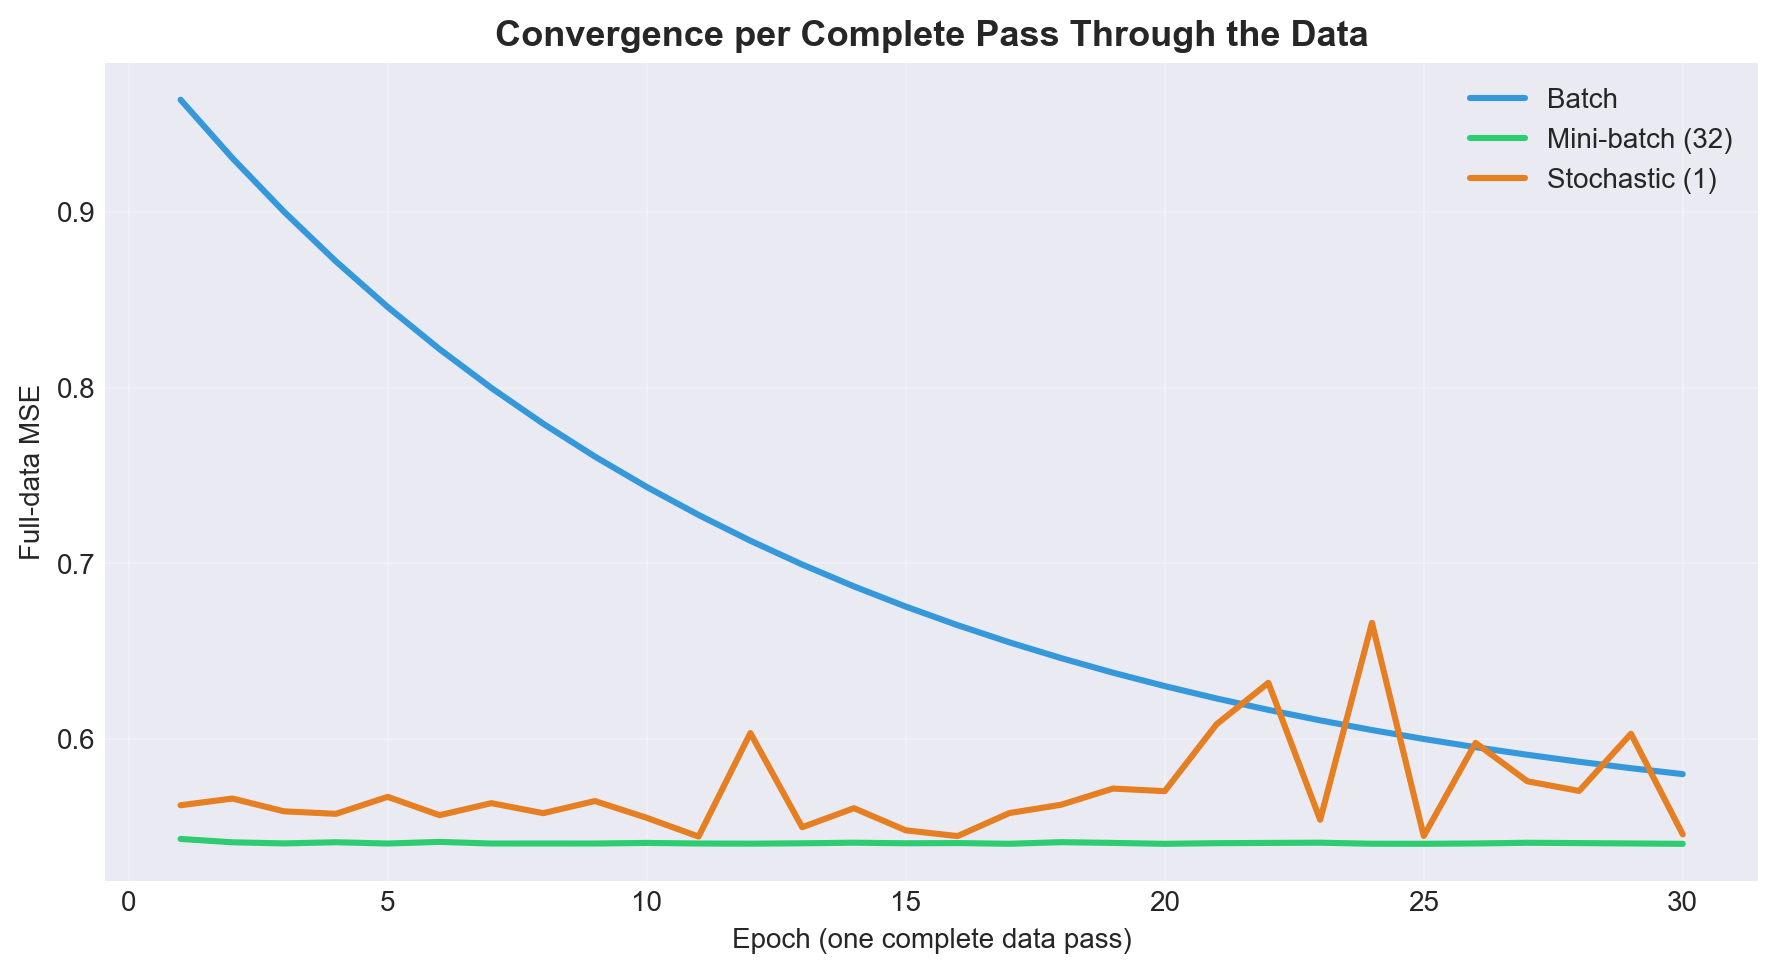

In [40]:
def optimize_in_batches(X, y, batch_size, learning_rate=0.02,
                        epochs=30, seed=42):
    # One shuffle and one complete pass through the data per epoch.
    rng = np.random.default_rng(seed)
    w = b = 0.0
    epoch_losses = []

    for _ in range(epochs):
        shuffled = rng.permutation(len(X))
        for start in range(0, len(X), batch_size):
            indices = shuffled[start:start + batch_size]
            errors = w * X[indices] + b - y[indices]
            w -= learning_rate * 2 * np.mean(X[indices] * errors)
            b -= learning_rate * 2 * np.mean(errors)
        epoch_losses.append(mse_loss(w, b))

    return np.asarray(epoch_losses)

batch_cases = [
    ('Batch', len(X), COLORS['optimum']),
    ('Mini-batch (32)', 32, COLORS['step']),
    ('Stochastic (1)', 1, COLORS['stochastic']),
]

fig, ax = plt.subplots(figsize=(9, 5))
for label, batch_size, color in batch_cases:
    losses = optimize_in_batches(X, y, batch_size=batch_size)
    ax.plot(np.arange(1, len(losses) + 1), losses,
            color=color, linewidth=2.2, label=label)

style_plot(ax, 'Convergence per Complete Pass Through the Data',
           'Epoch (one complete data pass)', 'Full-data MSE')
ax.legend()
plt.tight_layout()
plt.show()

## Wrap-Up

Optimization turns model training into movement through parameter space: residuals determine a gradient, the negative gradient supplies a local downhill direction, and the learning rate controls how far the model moves. Feature scaling changes the geometry of that journey, while batch size trades gradient precision for more frequent updates. Effective debugging therefore begins by reading the loss trajectory, checking scales and step size, and verifying that the gradient estimate matches the behavior you intend.


## Acknowledgment

California Housing data are provided by scikit-learn from the 1990 U.S. census.
